# Gemma 4 E4B vs Qwen3-8B — FP8 KV Cache Comparison

**Models:** google/gemma-4-E4B-it vs Qwen/Qwen3-8B  
**Configuration:** FP8 KV Cache on both models  
**Engine:** vLLM (V1 engine) on GKE — NVIDIA L4 (24 GB VRAM)  
**Load generator:** Locust (streaming SSE)  

| Dataset | Run ID | Model | Config |
|---------|--------|-------|--------|
| **Gemma 4** | `run_20260416_010036` | google/gemma-4-E4B-it | FP8 KV cache baseline |
| **Qwen3** | `run_20260405_005704` | Qwen/Qwen3-8B | FP8 KV cache |

**Concurrency levels:** 16, 32, 64, 128  
**Test duration:** 90 seconds per sub-test  
**GPU Hourly Cost:** $1.58/hr

In [1]:
import glob, json, os, textwrap, warnings, re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 200,
    'font.size': 10,
    'axes.titlesize': 12,
    'figure.titlesize': 14,
})

# ─── Configuration ────────────────────────────────────────────────────────────
RESULTS_ROOT = Path('results')
EVAL_ROOT    = Path('../evaluation/results')
OUTPUT_DIR   = RESULTS_ROOT / 'gemma4_vs_qwen3_comparison'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Run IDs
GEMMA4_RUN_ID = 'run_20260416_010036'
QWEN3_RUN_ID  = 'run_20260405_005704'

GEMMA4_EXP = 'gemma4_kv_fp8_baseline'
QWEN3_EXP  = 'qwen3_kv_cache_fp8'

# GPU cost (GKE pricing)
GPU_HOURLY_COST_USD = 1.58
TEST_DURATION_SEC   = 90

# Labels for plots
GEMMA4_LABEL = 'Gemma 4 E4B (FP8 KV)'
QWEN3_LABEL  = 'Qwen3-8B (FP8 KV)'
# ──────────────────────────────────────────────────────────────────────────────

In [2]:
# ─── Helper: load one experiment's Locust custom-metrics CSVs ────────────────
def load_experiment_locust(run_dir: Path, exp_name: str, model_label: str) -> pd.DataFrame:
    """Return a DataFrame with all custom_metrics rows, tagged with model / users."""
    exp_dir = run_dir / exp_name
    frames = []
    for csv_path in sorted(exp_dir.glob('*custom_metrics*.csv')):
        stem = csv_path.stem
        m = re.search(r'__u(\d+)', stem)
        users = int(m.group(1)) if m else 0
        df = pd.read_csv(csv_path)
        df['model'] = model_label
        df['users'] = users
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# ─── Helper: load one experiment's Prometheus metrics CSVs ───────────────────
def load_experiment_prometheus(run_dir: Path, exp_name: str, model_label: str) -> pd.DataFrame:
    """Return a DataFrame with all prometheus_metrics rows, tagged with model / users."""
    exp_dir = run_dir / exp_name
    frames = []
    for csv_path in sorted(exp_dir.glob('*prometheus_metrics*.csv')):
        stem = csv_path.stem
        m = re.search(r'__u(\d+)', stem)
        users = int(m.group(1)) if m else 0
        try:
            df = pd.read_csv(csv_path)
            df['model'] = model_label
            df['users'] = users
            frames.append(df)
        except Exception as e:
            print(f'Warning: {csv_path.name}: {e}')
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# ─── Load both experiments ───────────────────────────────────────────────────
gemma4_dir = RESULTS_ROOT / GEMMA4_RUN_ID
qwen3_dir  = RESULTS_ROOT / QWEN3_RUN_ID

df_gemma4 = load_experiment_locust(gemma4_dir, GEMMA4_EXP, GEMMA4_LABEL)
df_qwen3  = load_experiment_locust(qwen3_dir,  QWEN3_EXP,  QWEN3_LABEL)

df_all = pd.concat([df_gemma4, df_qwen3], ignore_index=True)
df_ok  = df_all[df_all['success'] == True].copy()

# Prometheus metrics
prom_gemma4 = load_experiment_prometheus(gemma4_dir, GEMMA4_EXP, GEMMA4_LABEL)
prom_qwen3  = load_experiment_prometheus(qwen3_dir,  QWEN3_EXP,  QWEN3_LABEL)
prom_all    = pd.concat([prom_gemma4, prom_qwen3], ignore_index=True)

print(f'Gemma 4: {len(df_gemma4):>5,} rows')
print(f'Qwen3  : {len(df_qwen3):>5,} rows')
print(f'──────────────────────────────────────────')
print(f'Total loaded   : {len(df_all):>5,}')
print(f'Successful     : {len(df_ok):>5,}  ({100*len(df_ok)/max(len(df_all),1):.1f}%)')
print(f'Failed         : {len(df_all)-len(df_ok):>5,}')
print(f'\nPrometheus metrics: {len(prom_all):,} rows')

df_ok.head(3)

Gemma 4:   420 rows
Qwen3  : 1,066 rows
──────────────────────────────────────────
Total loaded   : 1,486
Successful     : 1,486  (100.0%)
Failed         :     0

Prometheus metrics: 41,647 rows


,timestamp,category,approx_chars,output_tokens,ttft_ms,tpot_ms,e2e_ms,itl_p50_ms,itl_p99_ms,finish_reason,success,error_type,model,users
0,5445.459833,long,5997,82,281.688188,62.456648,5340.676665,42.957564,367.020050,stop,True,NaN,Gemma 4 E4B (FP8 KV),128
1,5446.406920,long,4811,147,648.383405,71.940760,11151.734292,47.315178,395.678411,stop,True,NaN,Gemma 4 E4B (FP8 KV),128
2,5468.255746,long,3697,16,588.960364,110.370204,2244.513431,58.899772,366.308098,stop,True,NaN,Gemma 4 E4B (FP8 KV),128


In [3]:
# ─── Percentile summary builder ───────────────────────────────────────────────
def pct(s, p):
    return s.quantile(p / 100)

def build_summary(df):
    return (
        df.groupby(['model', 'users'])
        .agg(
            n             = ('ttft_ms', 'count'),
            ttft_mean     = ('ttft_ms', 'mean'),
            ttft_p50      = ('ttft_ms', lambda s: pct(s, 50)),
            ttft_p95      = ('ttft_ms', lambda s: pct(s, 95)),
            ttft_p99      = ('ttft_ms', lambda s: pct(s, 99)),
            tpot_mean     = ('tpot_ms', 'mean'),
            tpot_p50      = ('tpot_ms', lambda s: pct(s, 50)),
            tpot_p99      = ('tpot_ms', lambda s: pct(s, 99)),
            e2e_mean      = ('e2e_ms', 'mean'),
            e2e_p50       = ('e2e_ms', lambda s: pct(s, 50)),
            e2e_p99       = ('e2e_ms', lambda s: pct(s, 99)),
            itl_p50_mean  = ('itl_p50_ms', 'mean'),
            itl_p99_mean  = ('itl_p99_ms', 'mean'),
            output_tokens = ('output_tokens', 'sum'),
        )
        .reset_index()
    )

summary = build_summary(df_ok)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.1f}'.format)

print('Comparison summary:')
display(summary)

Comparison summary:


,model,users,n,ttft_mean,ttft_p50,ttft_p95,ttft_p99,tpot_mean,tpot_p50,tpot_p99,e2e_mean,e2e_p50,e2e_p99,itl_p50_mean,itl_p99_mean,output_tokens
0,Gemma 4 E4B (FP8 KV),16,83,637.1,330.9,1026.0,8514.4,48.5,47.3,82.0,48528.4,46717.9,116254.9,44.4,109.2,83595
1,Gemma 4 E4B (FP8 KV),32,159,345.3,355.7,591.5,693.5,57.0,57.4,66.8,48945.9,46153.3,154458.0,51.2,274.1,137604
2,Gemma 4 E4B (FP8 KV),128,178,535.8,525.3,968.8,1136.3,97.5,102.0,120.2,90712.2,85995.1,252324.8,78.5,370.7,169203
3,Qwen3-8B (FP8 KV),16,115,551.0,376.0,754.7,7366.2,52.9,52.4,74.7,47005.7,41413.3,121094.8,48.4,167.2,101555
4,Qwen3-8B (FP8 KV),32,224,385.0,365.6,739.1,885.7,65.6,65.7,91.3,51406.0,46509.5,185582.0,58.1,319.8,176191
5,Qwen3-8B (FP8 KV),64,329,432.3,405.1,816.1,941.0,91.7,93.6,121.9,71778.0,69591.2,203246.8,78.3,392.5,264479
6,Qwen3-8B (FP8 KV),128,398,30302.2,36215.9,63593.7,69405.6,128.7,124.7,249.2,127273.5,124352.7,314910.1,96.8,471.5,323947


---
## 1. Latency Comparison — TTFT, TPOT, E2E

Comparing how both models behave under identical concurrency levels with FP8 KV cache.

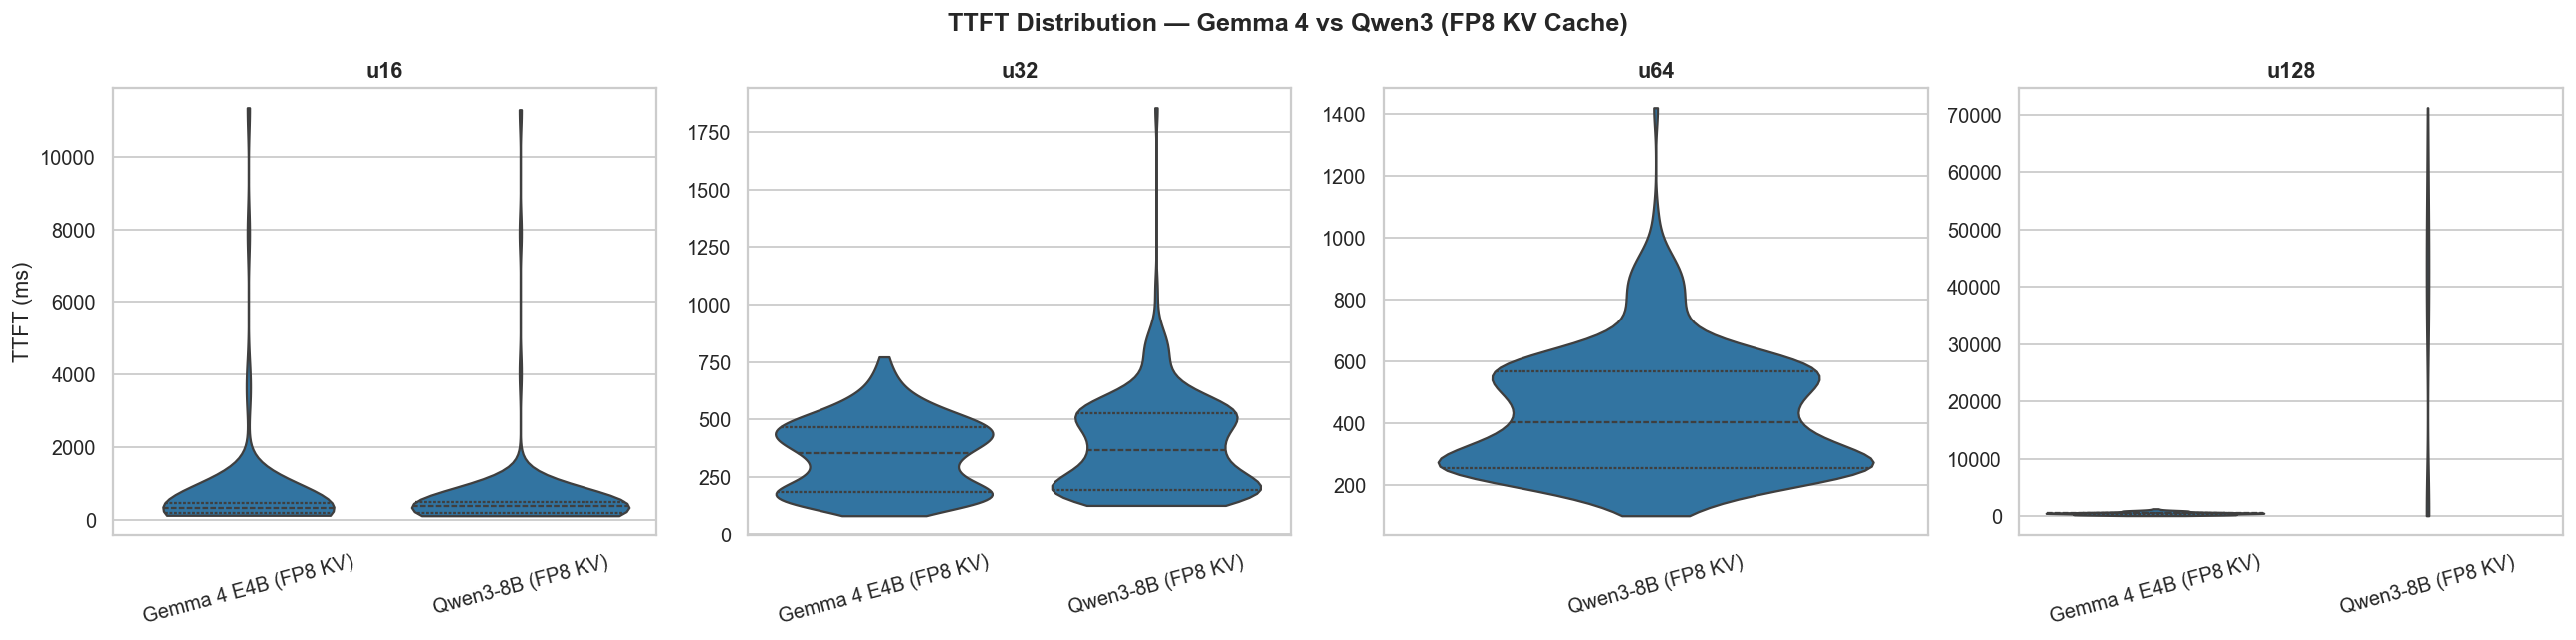

In [4]:
# ─── TTFT Violin Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)
fig.suptitle('TTFT Distribution — Gemma 4 vs Qwen3 (FP8 KV Cache)', fontsize=14, fontweight='bold')

for i, u in enumerate([16, 32, 64, 128]):
    ax = axes[i]
    subset = df_ok[df_ok['users'] == u]
    if len(subset) > 0:
        sns.violinplot(data=subset, x='model', y='ttft_ms', ax=ax, cut=0, inner='quartile')
    ax.set_title(f'u{u}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('TTFT (ms)' if i == 0 else '')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'ttft_violin.png', bbox_inches='tight')
plt.show()

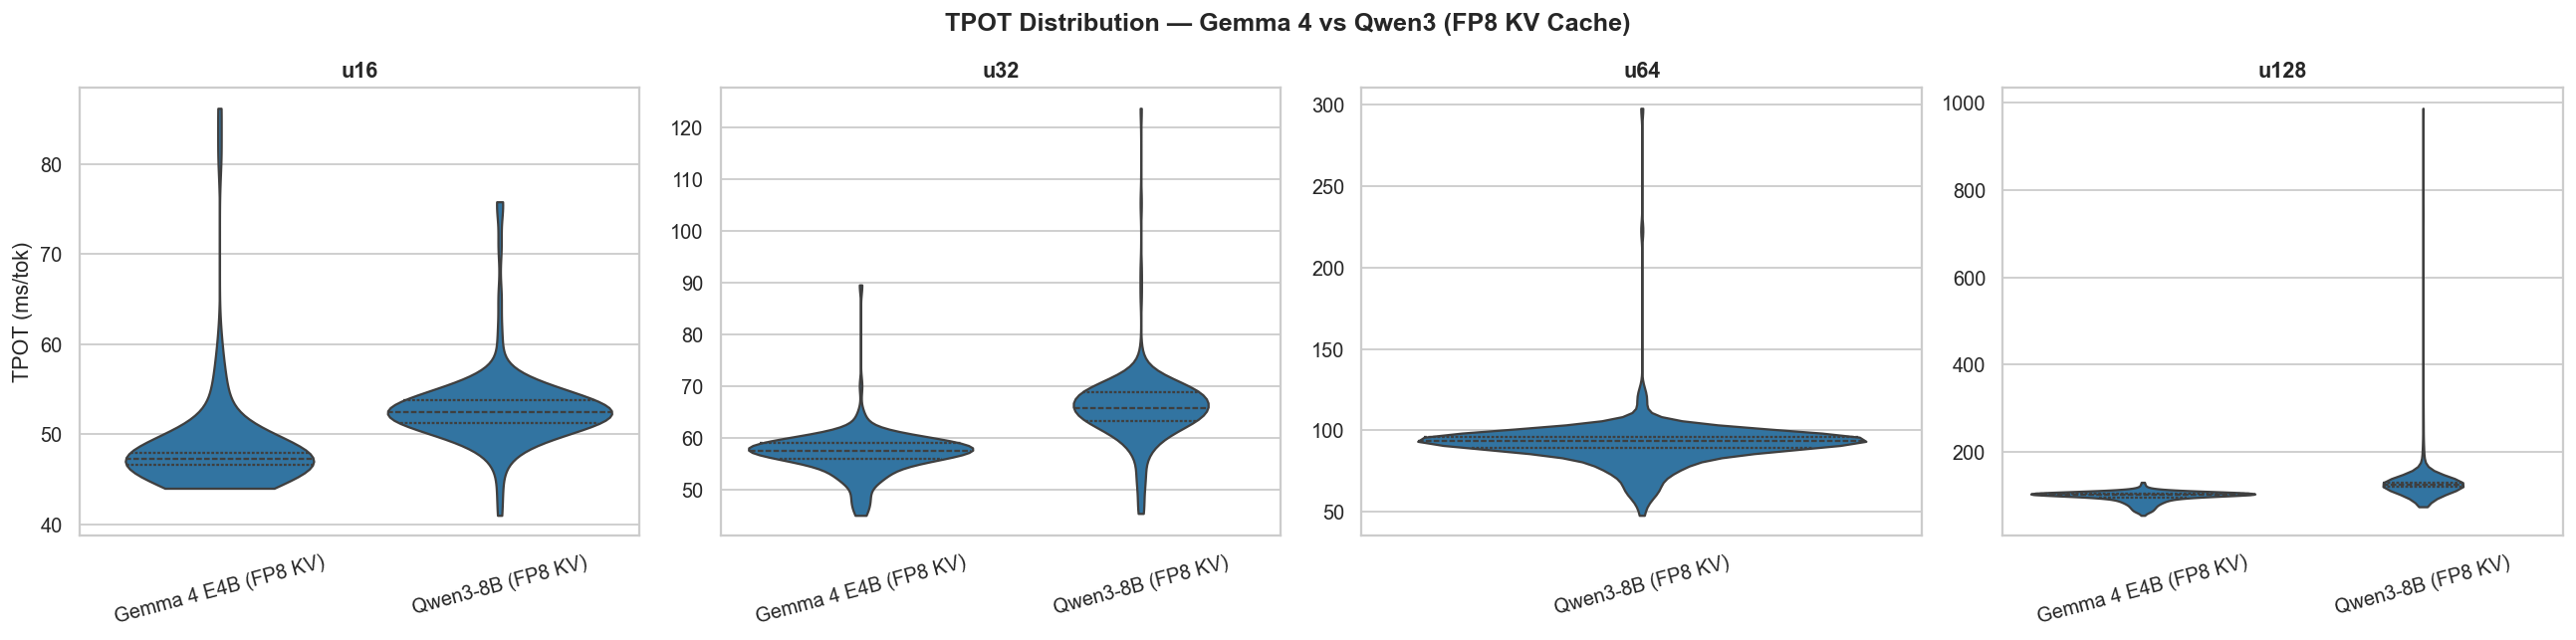

In [5]:
# ─── TPOT Violin Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)
fig.suptitle('TPOT Distribution — Gemma 4 vs Qwen3 (FP8 KV Cache)', fontsize=14, fontweight='bold')

for i, u in enumerate([16, 32, 64, 128]):
    ax = axes[i]
    subset = df_ok[df_ok['users'] == u]
    if len(subset) > 0:
        sns.violinplot(data=subset, x='model', y='tpot_ms', ax=ax, cut=0, inner='quartile')
    ax.set_title(f'u{u}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('TPOT (ms/tok)' if i == 0 else '')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'tpot_violin.png', bbox_inches='tight')
plt.show()

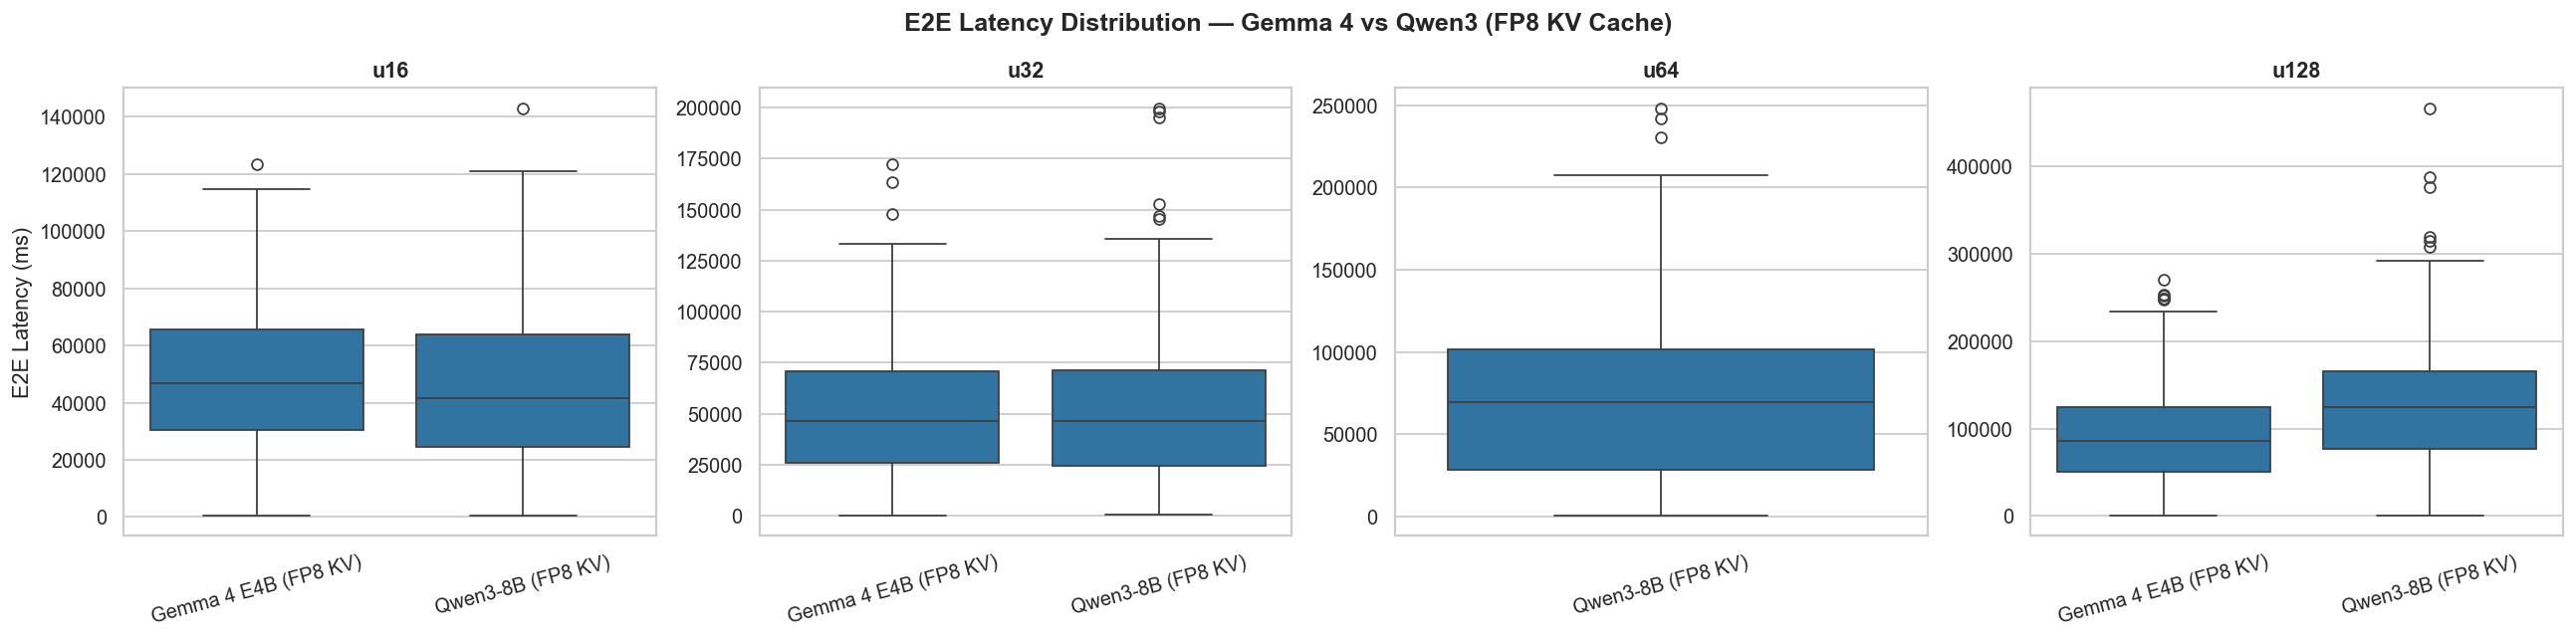

In [6]:
# ─── E2E Latency Box Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)
fig.suptitle('E2E Latency Distribution — Gemma 4 vs Qwen3 (FP8 KV Cache)', fontsize=14, fontweight='bold')

for i, u in enumerate([16, 32, 64, 128]):
    ax = axes[i]
    subset = df_ok[df_ok['users'] == u]
    if len(subset) > 0:
        sns.boxplot(data=subset, x='model', y='e2e_ms', ax=ax)
    ax.set_title(f'u{u}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('E2E Latency (ms)' if i == 0 else '')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'e2e_boxplot.png', bbox_inches='tight')
plt.show()

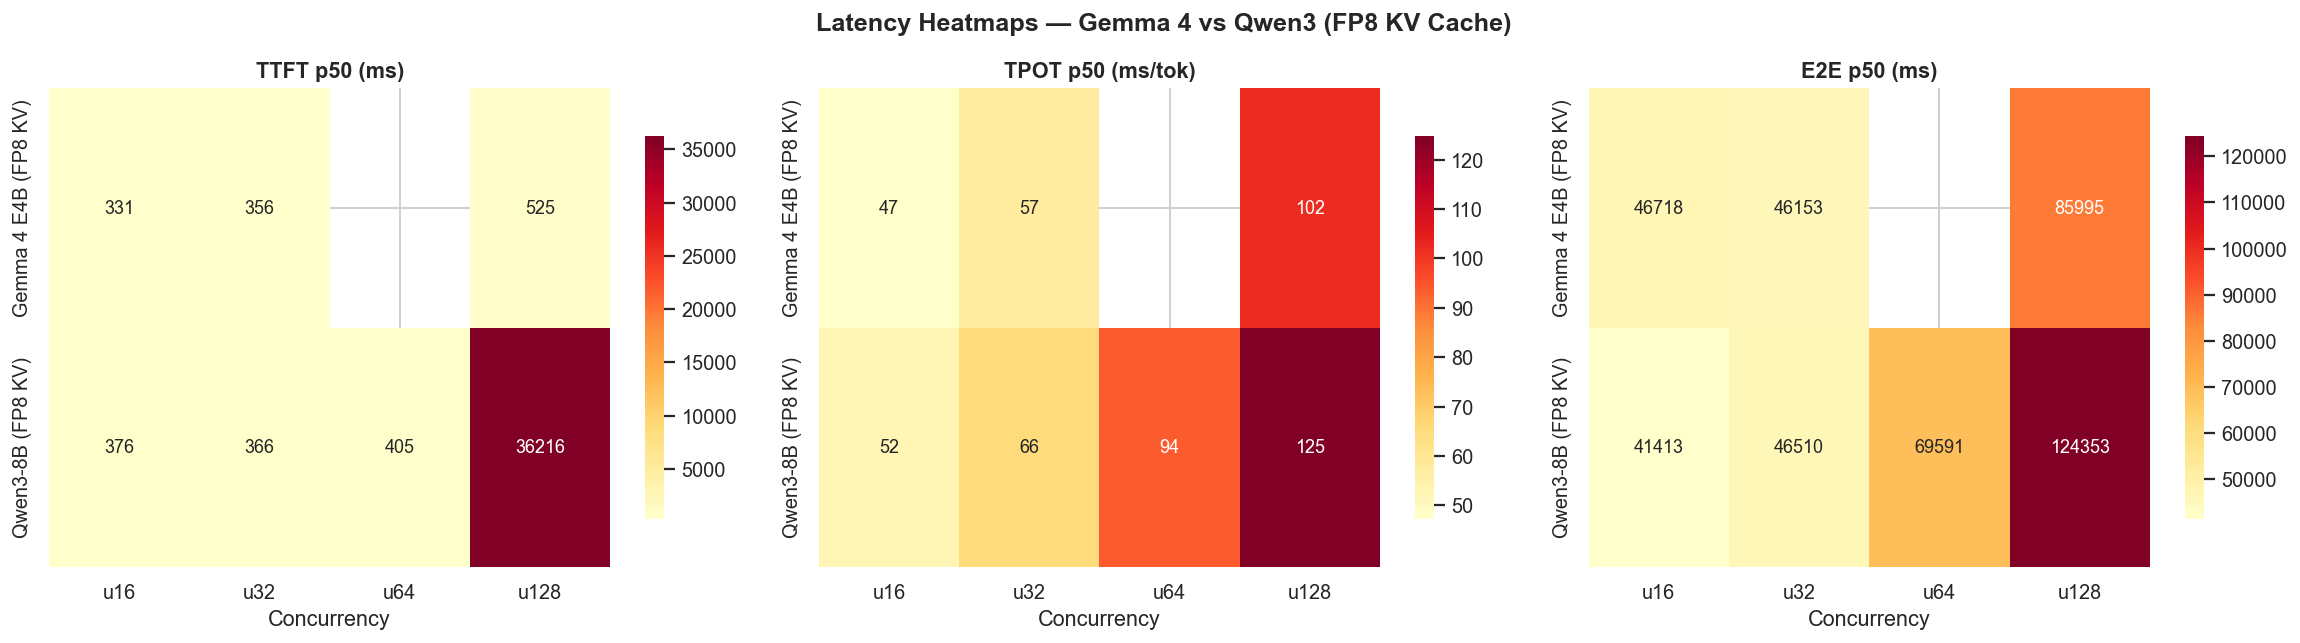

In [7]:
# ─── Latency Heatmaps ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Latency Heatmaps — Gemma 4 vs Qwen3 (FP8 KV Cache)', fontsize=14, fontweight='bold')

metrics = [('ttft_p50', 'TTFT p50 (ms)'), ('tpot_p50', 'TPOT p50 (ms/tok)'), ('e2e_p50', 'E2E p50 (ms)')]

for i, (col, title) in enumerate(metrics):
    ax = axes[i]
    pivot = summary.pivot_table(index='model', columns='users', values=col)
    pivot.columns = [f'u{c}' for c in pivot.columns]
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('')
    ax.set_xlabel('Concurrency')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'latency_heatmaps.png', bbox_inches='tight')
plt.show()

---
## 2. Throughput & Cost Comparison

In [8]:
# ─── Compute throughput and cost ──────────────────────────────────────────────
summary['throughput_tps'] = summary['output_tokens'] / TEST_DURATION_SEC
summary['cost_per_M_tok'] = (GPU_HOURLY_COST_USD / 3600 * TEST_DURATION_SEC) / summary['output_tokens'] * 1e6

print('Throughput & Cost Summary:')
display(summary[['model', 'users', 'n', 'output_tokens', 'throughput_tps', 'cost_per_M_tok']])

Throughput & Cost Summary:


,model,users,n,output_tokens,throughput_tps,cost_per_M_tok
0,Gemma 4 E4B (FP8 KV),16,83,83595,928.8,0.5
1,Gemma 4 E4B (FP8 KV),32,159,137604,1528.9,0.3
2,Gemma 4 E4B (FP8 KV),128,178,169203,1880.0,0.2
3,Qwen3-8B (FP8 KV),16,115,101555,1128.4,0.4
4,Qwen3-8B (FP8 KV),32,224,176191,1957.7,0.2
5,Qwen3-8B (FP8 KV),64,329,264479,2938.7,0.1
6,Qwen3-8B (FP8 KV),128,398,323947,3599.4,0.1


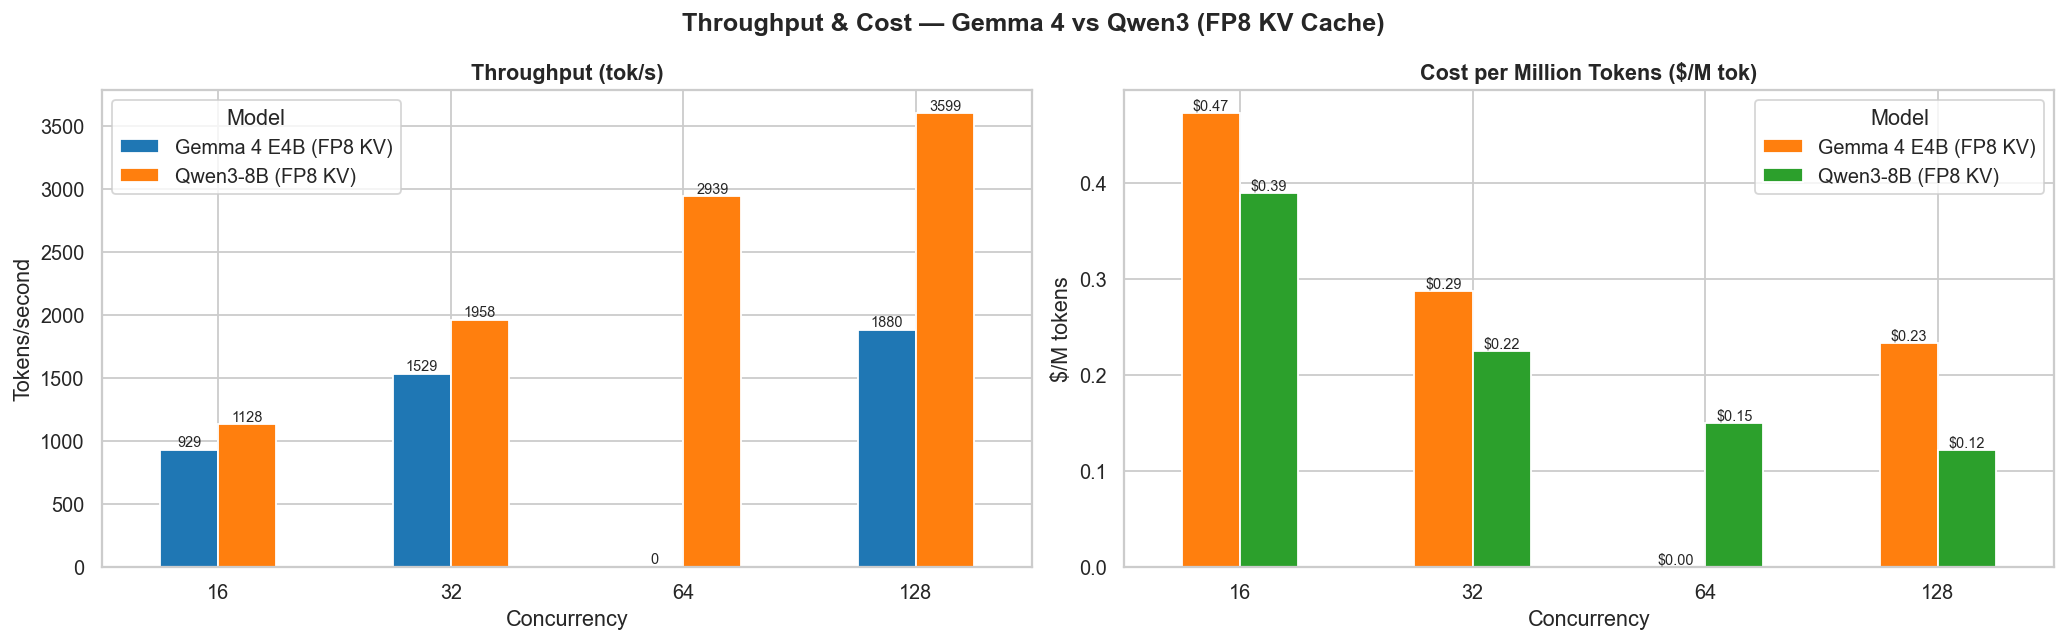

In [9]:
# ─── Throughput Bar Chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Throughput & Cost — Gemma 4 vs Qwen3 (FP8 KV Cache)', fontsize=14, fontweight='bold')

# Throughput
ax = axes[0]
pivot_tp = summary.pivot_table(index='users', columns='model', values='throughput_tps')
pivot_tp.plot(kind='bar', ax=ax, rot=0)
ax.set_title('Throughput (tok/s)', fontweight='bold')
ax.set_xlabel('Concurrency')
ax.set_ylabel('Tokens/second')
ax.legend(title='Model')
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f', fontsize=8)

# Cost
ax = axes[1]
pivot_cost = summary.pivot_table(index='users', columns='model', values='cost_per_M_tok')
pivot_cost.plot(kind='bar', ax=ax, rot=0, color=['tab:orange', 'tab:green'])
ax.set_title('Cost per Million Tokens ($/M tok)', fontweight='bold')
ax.set_xlabel('Concurrency')
ax.set_ylabel('$/M tokens')
ax.legend(title='Model')
for c in ax.containers:
    ax.bar_label(c, fmt='$%.2f', fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'throughput_cost.png', bbox_inches='tight')
plt.show()

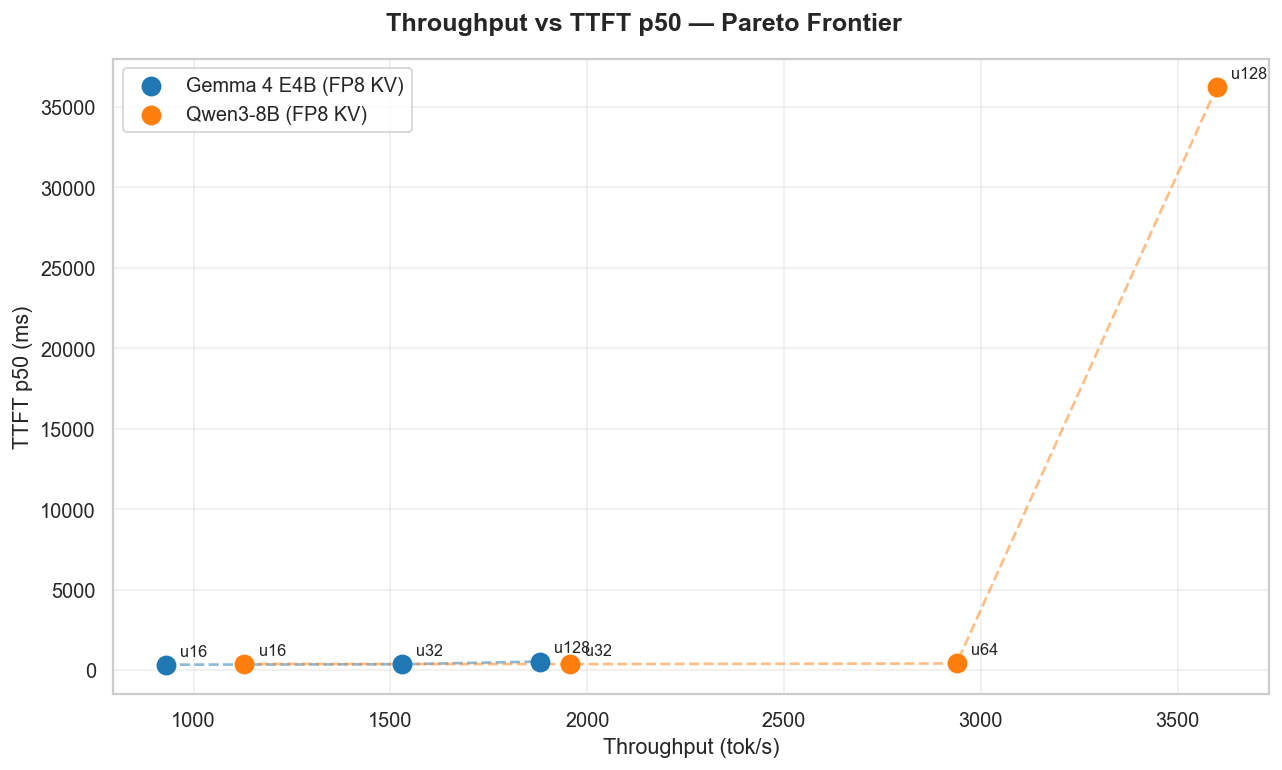

In [10]:
# ─── Pareto Frontier: Throughput vs Latency ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Throughput vs TTFT p50 — Pareto Frontier', fontsize=14, fontweight='bold')

for model in [GEMMA4_LABEL, QWEN3_LABEL]:
    mask = summary['model'] == model
    sub = summary[mask]
    ax.scatter(sub['throughput_tps'], sub['ttft_p50'], s=100, label=model, zorder=5)
    ax.plot(sub['throughput_tps'], sub['ttft_p50'], '--', alpha=0.5)
    for _, row in sub.iterrows():
        ax.annotate(f'u{int(row["users"])}', (row['throughput_tps'], row['ttft_p50']),
                    textcoords='offset points', xytext=(8, 5), fontsize=9)

ax.set_xlabel('Throughput (tok/s)')
ax.set_ylabel('TTFT p50 (ms)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'pareto_frontier.png', bbox_inches='tight')
plt.show()

---
## 3. Server-Side Metrics (Prometheus)

In [11]:
# ─── Server Metrics Summary Table ─────────────────────────────────────────────
metric_map = {
    'gpu_utilization':          'GPU Util %',
    'gpu_memory_used_mb':       'VRAM (MiB)',
    'kv_cache_utilization':     'KV Cache %',
    'generation_throughput':    'Gen TPS',
    'num_waiting_requests':     'Queue Wait',
}

rows = []
for model in [GEMMA4_LABEL, QWEN3_LABEL]:
    for u in [16, 32, 64, 128]:
        mask = (prom_all['model'] == model) & (prom_all['users'] == u)
        sub = prom_all[mask]
        if len(sub) == 0:
            continue
        row = {'Model': model, 'Concurrency': f'u{u}'}
        for metric_key, col_name in metric_map.items():
            vals = sub[sub['metric_name'] == metric_key]['value'].astype(float)
            row[col_name] = f'{vals.mean():.1f}' if len(vals) > 0 else 'N/A'
        rows.append(row)

server_df = pd.DataFrame(rows)
print('Server-Side Metrics Summary:')
display(server_df)

Server-Side Metrics Summary:


,Model,Concurrency,GPU Util %,VRAM (MiB),KV Cache %,Gen TPS,Queue Wait
0,Gemma 4 E4B (FP8 KV),u16,N/A,N/A,N/A,N/A,N/A
1,Gemma 4 E4B (FP8 KV),u32,N/A,N/A,N/A,N/A,N/A
2,Gemma 4 E4B (FP8 KV),u64,N/A,N/A,N/A,N/A,N/A
3,Gemma 4 E4B (FP8 KV),u128,N/A,N/A,N/A,N/A,N/A
4,Qwen3-8B (FP8 KV),u16,N/A,N/A,N/A,N/A,N/A
5,Qwen3-8B (FP8 KV),u32,N/A,N/A,N/A,N/A,N/A
6,Qwen3-8B (FP8 KV),u64,N/A,N/A,N/A,N/A,N/A
7,Qwen3-8B (FP8 KV),u128,N/A,N/A,N/A,N/A,N/A


/var/folders/y0/glglx_dn5nz0n_vpk90j3vl40000gn/T/ipykernel_27524/2398520690.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


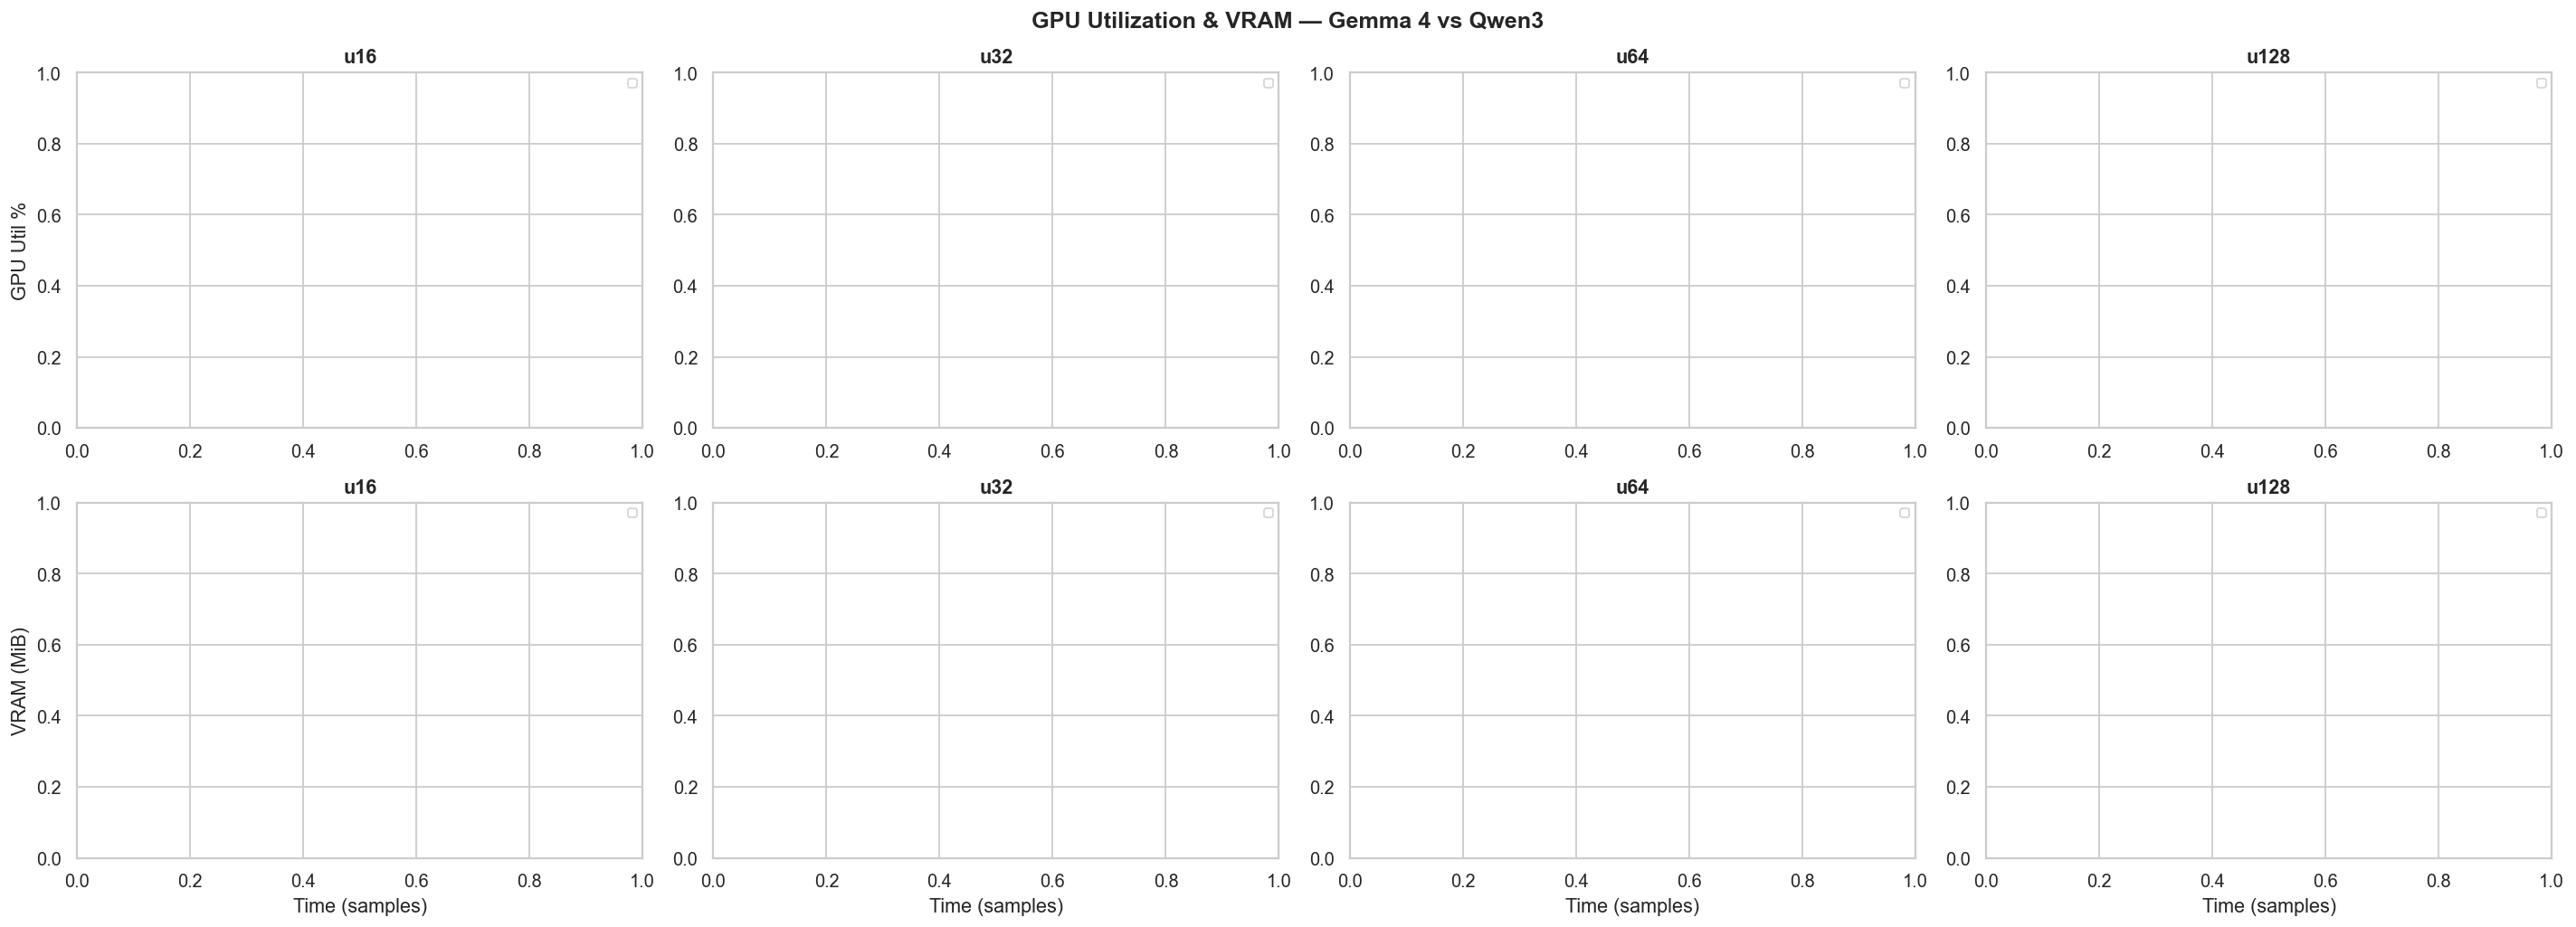

In [12]:
# ─── GPU Utilization & VRAM Time Series ──────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 8), sharex=False)
fig.suptitle('GPU Utilization & VRAM — Gemma 4 vs Qwen3', fontsize=14, fontweight='bold')

for i, u in enumerate([16, 32, 64, 128]):
    for j, (metric, ylabel) in enumerate([('gpu_utilization', 'GPU Util %'), ('gpu_memory_used_mb', 'VRAM (MiB)')]):
        ax = axes[j][i]
        for model, color in [(GEMMA4_LABEL, 'tab:blue'), (QWEN3_LABEL, 'tab:orange')]:
            mask = (prom_all['model'] == model) & (prom_all['users'] == u) & (prom_all['metric_name'] == metric)
            sub = prom_all[mask].copy()
            if len(sub) > 0:
                sub['value'] = sub['value'].astype(float)
                sub = sub.sort_values('timestamp')
                sub['t'] = range(len(sub))
                ax.plot(sub['t'], sub['value'], label=model, color=color, alpha=0.7)
        ax.set_title(f'u{u}', fontweight='bold')
        if i == 0:
            ax.set_ylabel(ylabel)
        if j == 1:
            ax.set_xlabel('Time (samples)')
        ax.legend(fontsize=7)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'gpu_utilization_timeseries.png', bbox_inches='tight')
plt.show()

/var/folders/y0/glglx_dn5nz0n_vpk90j3vl40000gn/T/ipykernel_27524/3679650415.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


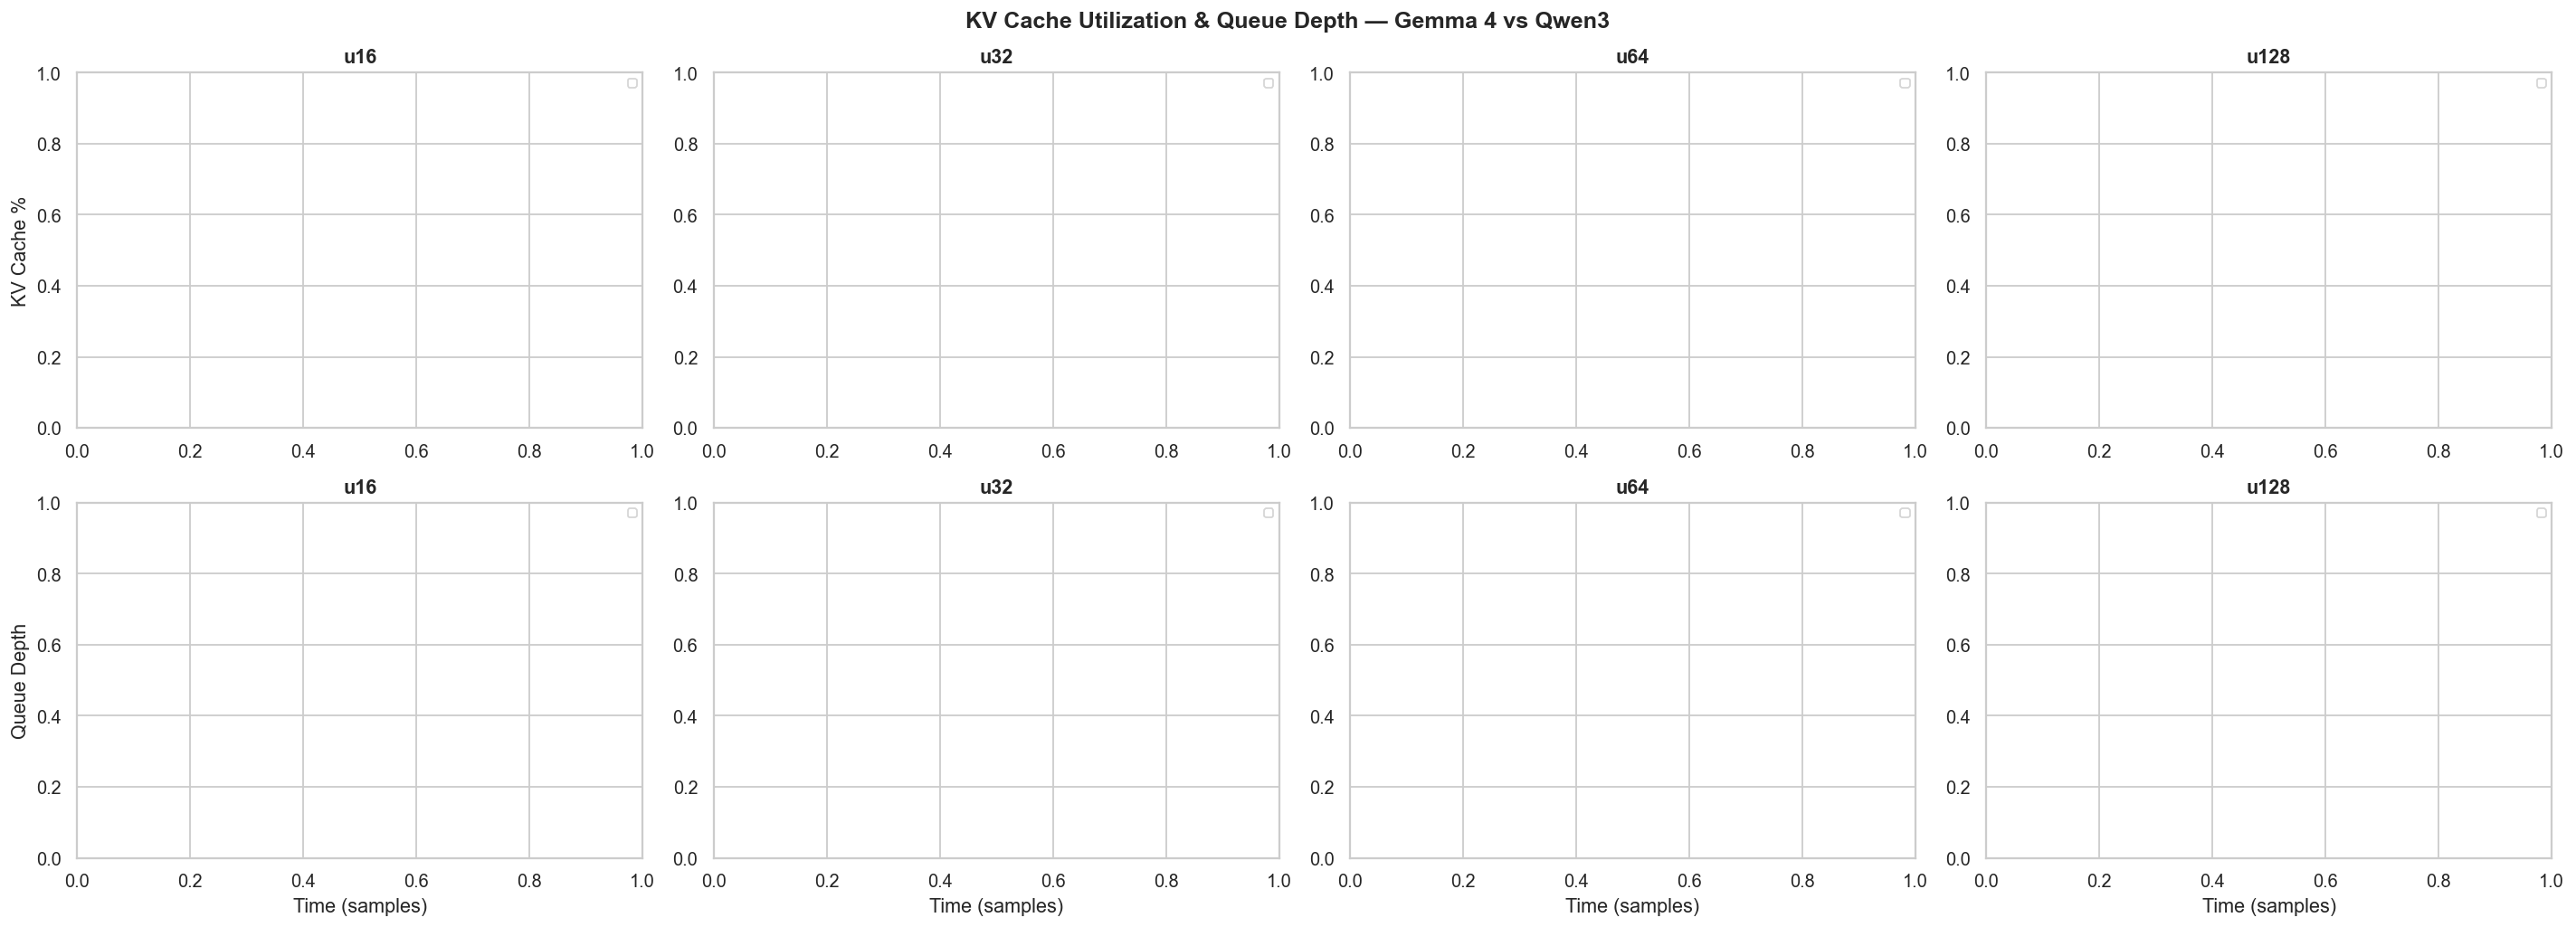

In [13]:
# ─── KV Cache & Queue Depth Time Series ──────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 8), sharex=False)
fig.suptitle('KV Cache Utilization & Queue Depth — Gemma 4 vs Qwen3', fontsize=14, fontweight='bold')

for i, u in enumerate([16, 32, 64, 128]):
    for j, (metric, ylabel) in enumerate([('kv_cache_utilization', 'KV Cache %'), ('num_waiting_requests', 'Queue Depth')]):
        ax = axes[j][i]
        for model, color in [(GEMMA4_LABEL, 'tab:blue'), (QWEN3_LABEL, 'tab:orange')]:
            mask = (prom_all['model'] == model) & (prom_all['users'] == u) & (prom_all['metric_name'] == metric)
            sub = prom_all[mask].copy()
            if len(sub) > 0:
                sub['value'] = sub['value'].astype(float)
                sub = sub.sort_values('timestamp')
                sub['t'] = range(len(sub))
                ax.plot(sub['t'], sub['value'], label=model, color=color, alpha=0.7)
        ax.set_title(f'u{u}', fontweight='bold')
        if i == 0:
            ax.set_ylabel(ylabel)
        if j == 1:
            ax.set_xlabel('Time (samples)')
        ax.legend(fontsize=7)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'kv_cache_timeseries.png', bbox_inches='tight')
plt.show()

---
## 4. ITL Analysis — Token Streaming Smoothness

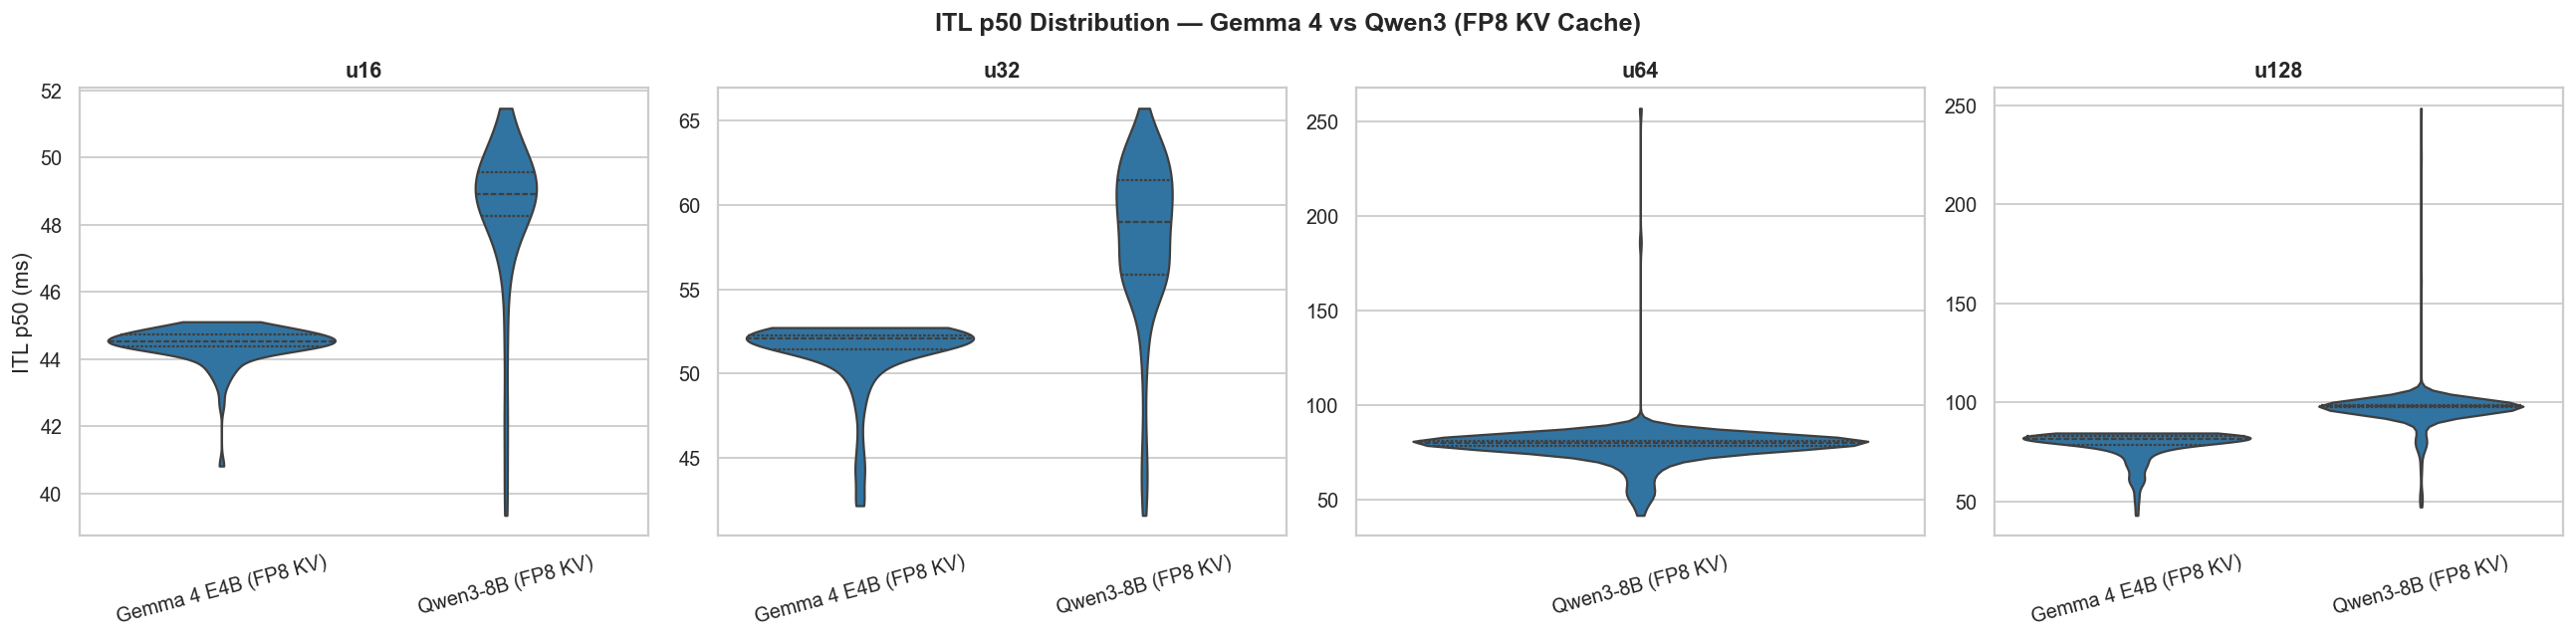

In [14]:
# ─── ITL Analysis ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)
fig.suptitle('ITL p50 Distribution — Gemma 4 vs Qwen3 (FP8 KV Cache)', fontsize=14, fontweight='bold')

for i, u in enumerate([16, 32, 64, 128]):
    ax = axes[i]
    subset = df_ok[df_ok['users'] == u]
    if len(subset) > 0:
        sns.violinplot(data=subset, x='model', y='itl_p50_ms', ax=ax, cut=0, inner='quartile')
    ax.set_title(f'u{u}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('ITL p50 (ms)' if i == 0 else '')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'itl_analysis.png', bbox_inches='tight')
plt.show()

---
## 5. Latency Scaling — How Metrics Change with Concurrency

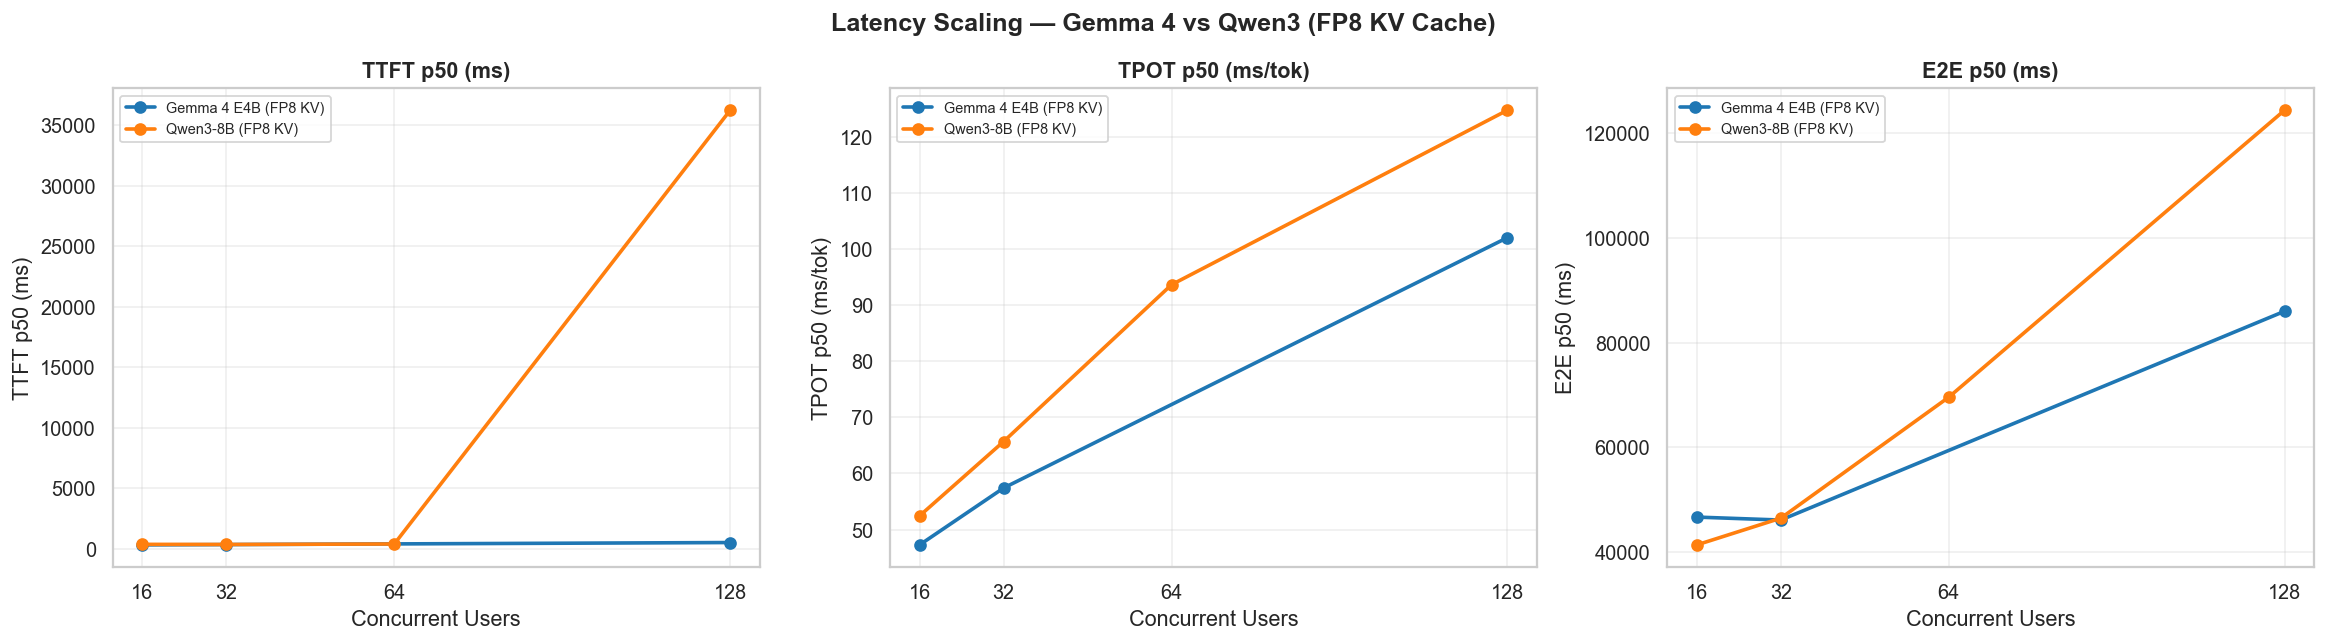

In [15]:
# ─── Latency Scaling ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Latency Scaling — Gemma 4 vs Qwen3 (FP8 KV Cache)', fontsize=14, fontweight='bold')

metrics_scaling = [('ttft_p50', 'TTFT p50 (ms)'), ('tpot_p50', 'TPOT p50 (ms/tok)'), ('e2e_p50', 'E2E p50 (ms)')]

for i, (col, title) in enumerate(metrics_scaling):
    ax = axes[i]
    for model in [GEMMA4_LABEL, QWEN3_LABEL]:
        sub = summary[summary['model'] == model]
        ax.plot(sub['users'], sub[col], marker='o', linewidth=2, label=model)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Concurrent Users')
    ax.set_ylabel(title)
    ax.legend(fontsize=8)
    ax.set_xticks([16, 32, 64, 128])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'latency_scaling.png', bbox_inches='tight')
plt.show()

---
## 6. Relative Performance — Gemma 4 vs Qwen3

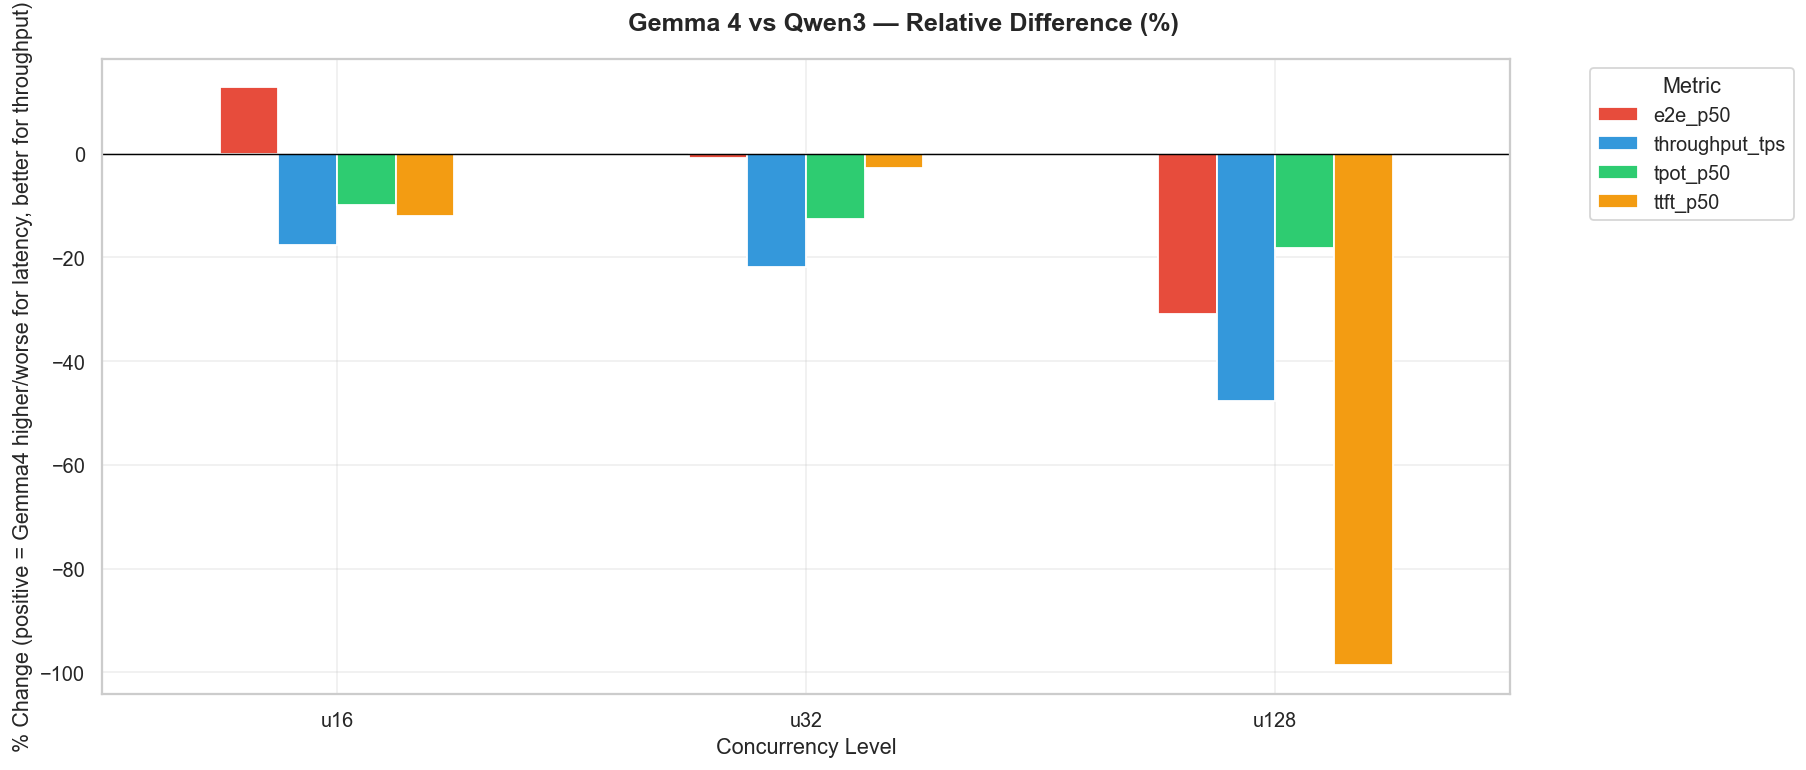


Relative performance table (Gemma4 vs Qwen3 — positive means Gemma4 is HIGHER):


Metric,e2e_p50,throughput_tps,tpot_p50,ttft_p50
Concurrency,,,,
u128,-30.8,-47.8,-18.2,-98.5
u16,12.8,-17.7,-9.9,-12.0
u32,-0.8,-21.9,-12.6,-2.7


In [16]:
# ─── Improvement / Degradation Chart ──────────────────────────────────────────
# Compare Gemma4 to Qwen3 as % change
gemma_sub = summary[summary['model'] == GEMMA4_LABEL].set_index('users')
qwen_sub  = summary[summary['model'] == QWEN3_LABEL].set_index('users')

# Get common users
common_users = sorted(set(gemma_sub.index) & set(qwen_sub.index))

pct_changes = []
for u in common_users:
    for metric in ['ttft_p50', 'tpot_p50', 'e2e_p50', 'throughput_tps']:
        g_val = gemma_sub.loc[u, metric]
        q_val = qwen_sub.loc[u, metric]
        pct_change = (g_val - q_val) / q_val * 100
        pct_changes.append({'Concurrency': f'u{u}', 'Metric': metric, '% Change (Gemma4 vs Qwen3)': pct_change})

pct_df = pd.DataFrame(pct_changes)

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Gemma 4 vs Qwen3 — Relative Difference (%)', fontsize=14, fontweight='bold')

pivot_pct = pct_df.pivot_table(index='Concurrency', columns='Metric', values='% Change (Gemma4 vs Qwen3)')
pivot_pct = pivot_pct.reindex([f'u{u}' for u in common_users])

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
pivot_pct.plot(kind='bar', ax=ax, rot=0, color=colors)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('% Change (positive = Gemma4 higher/worse for latency, better for throughput)')
ax.set_xlabel('Concurrency Level')
ax.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'relative_comparison.png', bbox_inches='tight')
plt.show()

print('\nRelative performance table (Gemma4 vs Qwen3 — positive means Gemma4 is HIGHER):')
display(pct_df.pivot_table(index='Concurrency', columns='Metric', values='% Change (Gemma4 vs Qwen3)').round(1))

---
## 7. Quality Evaluation (Accuracy)

In [17]:
# ─── Quality Evaluation Data ──────────────────────────────────────────────────
# Load evaluation results from JSON files
def load_eval_score(json_path: Path, benchmark: str):
    """Extract the main accuracy score from an lm-evaluation-harness results file."""
    try:
        with open(json_path) as f:
            data = json.load(f)
        results = data.get('results', {})
        if benchmark in results:
            r = results[benchmark]
            if 'acc,none' in r:
                return r['acc,none']
            elif 'acc_norm,none' in r:
                return r['acc_norm,none']
            elif 'exact_match,strict-match' in r:
                return r['exact_match,strict-match']
    except Exception:
        pass
    return None

# Build quality comparison table
qual_data = []

# Gemma4 FP8 — non-reasoning
gemma4_eval_base = EVAL_ROOT / 'gemma4' / 'fp8-model&fp8-kv-cache'
for mode in ['non-reasoning', 'reasoning']:
    mode_dir = gemma4_eval_base / mode
    if mode_dir.exists():
        for bench_dir in mode_dir.iterdir():
            if bench_dir.is_dir():
                bench = bench_dir.name
                for json_file in bench_dir.glob('results_*.json'):
                    score = load_eval_score(json_file, bench)
                    if score is not None:
                        qual_data.append({
                            'Model': 'Gemma 4 E4B',
                            'Config': f'FP8 ({mode})',
                            'Benchmark': bench.upper().replace('_', '-'),
                            'Score': score
                        })

# Qwen3 FP8
qwen3_eval_base = EVAL_ROOT / 'qwen-3' / 'fp8-model&fp8-kv-cache'
if qwen3_eval_base.exists():
    for mode in ['reasoning']:
        mode_dir = qwen3_eval_base / mode
        if mode_dir.exists():
            for bench_dir in mode_dir.iterdir():
                if bench_dir.is_dir():
                    bench = bench_dir.name
                    for json_file in bench_dir.glob('results_*.json'):
                        score = load_eval_score(json_file, bench)
                        if score is not None:
                            qual_data.append({
                                'Model': 'Qwen3-8B',
                                'Config': f'FP8 ({mode})',
                                'Benchmark': bench.upper().replace('_', '-'),
                                'Score': score
                            })

qual_df = pd.DataFrame(qual_data)
print('Quality Evaluation Results:')
display(qual_df.pivot_table(index=['Model', 'Config'], columns='Benchmark', values='Score').round(3))

Quality Evaluation Results:


Benchmark                        ARC-CHALLENGE  GSM8K  MMLU
Model       Config                                         
Gemma 4 E4B FP8 (non-reasoning)            0.3    0.7   NaN
            FP8 (reasoning)                0.3    0.7   NaN
Qwen3-8B    FP8 (reasoning)                0.7    0.9   0.8

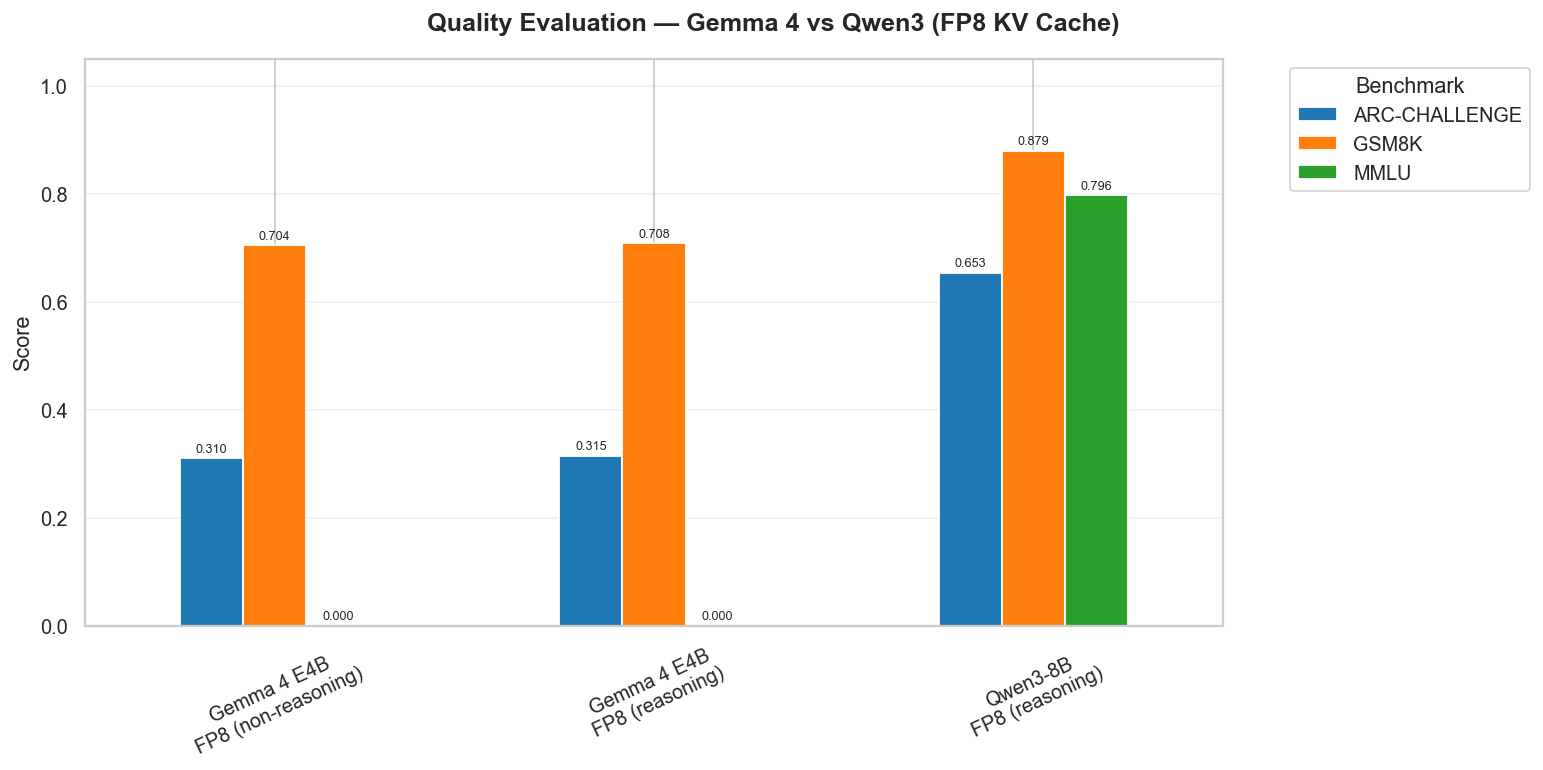

In [18]:
# ─── Quality Comparison Bar Chart ─────────────────────────────────────────────
if len(qual_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.suptitle('Quality Evaluation — Gemma 4 vs Qwen3 (FP8 KV Cache)', fontsize=14, fontweight='bold')

    # Create a combined label
    qual_df['Label'] = qual_df['Model'] + '\n' + qual_df['Config']

    pivot_qual = qual_df.pivot_table(index='Label', columns='Benchmark', values='Score')
    pivot_qual.plot(kind='bar', ax=ax, rot=25)

    ax.set_ylabel('Score')
    ax.set_xlabel('')
    ax.legend(title='Benchmark', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, axis='y')

    for c in ax.containers:
        ax.bar_label(c, fmt='%.3f', fontsize=7, padding=2)

    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / 'quality_comparison.png', bbox_inches='tight')
    plt.show()
else:
    print('No quality evaluation data available.')

---
## 8. Summary — Key Metrics at a Glance

In [19]:
# ─── Final Comparison Table ───────────────────────────────────────────────────
print('\n' + '='*80)
print('FINAL COMPARISON SUMMARY — Gemma 4 E4B vs Qwen3-8B (FP8 KV Cache)')
print('='*80)

cols_to_show = ['model', 'users', 'n', 'ttft_p50', 'tpot_p50', 'e2e_p50', 'throughput_tps', 'cost_per_M_tok']
final = summary[cols_to_show].copy()
final.columns = ['Model', 'Users', 'Requests', 'TTFT p50 (ms)', 'TPOT p50 (ms/tok)', 'E2E p50 (ms)', 'Throughput (tok/s)', 'Cost ($/M tok)']

pd.set_option('display.float_format', '{:.1f}'.format)
display(final)

print('\n📁 All figures saved to:', OUTPUT_DIR.resolve())


FINAL COMPARISON SUMMARY — Gemma 4 E4B vs Qwen3-8B (FP8 KV Cache)


,Model,Users,Requests,TTFT p50 (ms),TPOT p50 (ms/tok),E2E p50 (ms),Throughput (tok/s),Cost ($/M tok)
0,Gemma 4 E4B (FP8 KV),16,83,330.9,47.3,46717.9,928.8,0.5
1,Gemma 4 E4B (FP8 KV),32,159,355.7,57.4,46153.3,1528.9,0.3
2,Gemma 4 E4B (FP8 KV),128,178,525.3,102.0,85995.1,1880.0,0.2
3,Qwen3-8B (FP8 KV),16,115,376.0,52.4,41413.3,1128.4,0.4
4,Qwen3-8B (FP8 KV),32,224,365.6,65.7,46509.5,1957.7,0.2
5,Qwen3-8B (FP8 KV),64,329,405.1,93.6,69591.2,2938.7,0.1
6,Qwen3-8B (FP8 KV),128,398,36215.9,124.7,124352.7,3599.4,0.1



📁 All figures saved to: /Users/erayyuklu/Documents/PERFORMANCE-EVALUATIONS-OF-LLM-INFERENCE-FRAMEWORKS/benchmarking/results/gemma4_vs_qwen3_comparison
